CAS 781 Final Project - Empirical Study of Hyperparameter Sensitivity in RL

In [1]:

! python.exe -m pip install --upgrade pip
! pip install -r requirements.txt

   ---------------------------------------- 0.0/953.9 kB ? eta -:--:--
   ---------------------------------------- 953.9/953.9 kB 14.7 MB/s  0:00:00
   ---------------------------------------- 0.0/7.6 MB ? eta -:--:--
   ------------------------ --------------- 4.7/7.6 MB 21.8 MB/s eta 0:00:01
   ---------------------------------------- 7.6/7.6 MB 20.5 MB/s  0:00:00
   ---------------------------------------- 0.0/11.5 MB ? eta -:--:--
   ----------- ---------------------------- 3.4/11.5 MB 18.3 MB/s eta 0:00:01
   ----------------------- ---------------- 6.8/11.5 MB 16.8 MB/s eta 0:00:01
   ---------------------------------------  11.3/11.5 MB 19.0 MB/s eta 0:00:01
   ---------------------------------------- 11.5/11.5 MB 17.9 MB/s  0:00:00

  Attempting uninstall: tqdm

    Found existing installation: tqdm 4.66.5

    Uninstalling tqdm-4.66.5:

      Successfully uninstalled tqdm-4.66.5

   ---------------------------------------- 0/4 [tqdm]
   ----------------------------------------

In [2]:
# Installation test
import gymnasium as gym

env1 = gym.make("FrozenLake-v1", is_slippery=False)
env2 = gym.make("Taxi-v3")

print("FrozenLake:", env1.observation_space, env1.action_space)
print("Taxi:", env2.observation_space, env2.action_space)

FrozenLake: Discrete(16) Discrete(4)
Taxi: Discrete(500) Discrete(6)


In [3]:
from itertools import product
import pandas as pd

from src.env.env_factory import make_env
from src.algo.q_learning import QLearningConfig, run_q_learning
from src.utils.logging import save_results_csv, save_trajectory_csv, make_run_name
from src.utils.metrics import summarize_run, moving_average

In [37]:
"""
# Function test
env = make_env("frozenlake", seed=42)

config = QLearningConfig(
    alpha=0.1,
    gamma=0.99,
    epsilon=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.995,
    n_episodes=500,
    max_steps_per_episode=100,
    seed=42,
)

agent, training_logs, eval_logs = run_q_learning(env, config)

record = summarize_run(
    training_logs=training_logs,
    eval_logs=eval_logs,
    config=config,
    env_name="frozenlake",
    seed=42,
    success_threshold=1.0,
)

run_name = make_run_name(config, seed=42)

df = pd.DataFrame([record])
save_results_csv(df, f"results/raw/{run_name}_summary.csv")

save_trajectory_csv(
    training_logs,
    f"results/raw/trajectories/{run_name}.csv"
)
"""

'\n# Function test\nenv = make_env("frozenlake", seed=42)\n\nconfig = QLearningConfig(\n    alpha=0.1,\n    gamma=0.99,\n    epsilon=1.0,\n    epsilon_min=0.05,\n    epsilon_decay=0.995,\n    n_episodes=500,\n    max_steps_per_episode=100,\n    seed=42,\n)\n\nagent, training_logs, eval_logs = run_q_learning(env, config)\n\nrecord = summarize_run(\n    training_logs=training_logs,\n    eval_logs=eval_logs,\n    config=config,\n    env_name="frozenlake",\n    seed=42,\n    success_threshold=1.0,\n)\n\nrun_name = make_run_name(config, seed=42)\n\ndf = pd.DataFrame([record])\nsave_results_csv(df, f"results/raw/{run_name}_summary.csv")\n\nsave_trajectory_csv(\n    training_logs,\n    f"results/raw/trajectories/{run_name}.csv"\n)\n'

Experiment w/ Frozenlake ENV

In [4]:
from src.utils.logging import records_to_dataframe, load_reward_sequences
from src.utils.plotting import plot_rewards, plot_heatmap, plot_heatmap_annotated, plot_multi_run_curve, plot_multi_run_comparison

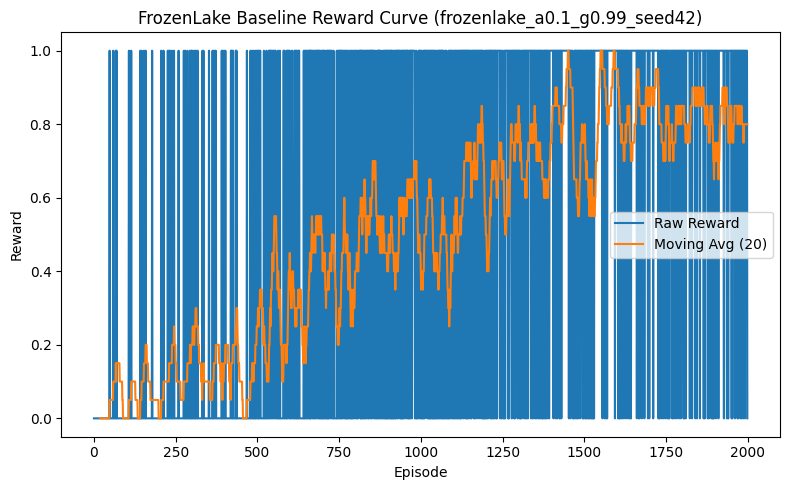

{'mean_reward': 1.0, 'std_reward': 0.0, 'mean_length': 6.0, 'std_length': 0.0}


,env,seed,alpha,gamma,epsilon_init,epsilon_min,epsilon_decay,n_episodes,max_steps_per_episode,train_reward_final,...,train_length_last_50_mean,train_length_last_100_mean,success_rate_last_100,first_success_episode,convergence_episode,best_moving_avg_reward_20,eval_mean_reward,eval_std_reward,eval_mean_length,eval_std_length
0,frozenlake,42,0.1,0.99,0.1352,0.05,0.999,2000,100,0.0,...,6.22,6.33,0.82,49,1157,1.0,1.0,0.0,6.0,0.0


In [39]:
env = gym.make(
    "FrozenLake-v1",
    is_slippery=False,
)

# Baseline config
base_config = QLearningConfig(
    alpha=0.1,
    gamma=0.99,
    epsilon=1.0,
    epsilon_min=0.05,
    epsilon_decay = 0.999,
    n_episodes=2000,
    max_steps_per_episode=100,
    seed=42,
)

#Testing args
small_alphas = [0.1, 0.3] # Learning rate
small_gammas = [0.9, 0.99] # Discount
small_seeds = [0, 1, 2] # Seeds

agent, training_logs, eval_logs = run_q_learning(env, base_config)

record = summarize_run(
    training_logs=training_logs,
    eval_logs=eval_logs,
    config=base_config,
    env_name="frozenlake",
    seed=42,
    success_threshold=1.0,
)

run_name = make_run_name(base_config, env_name="frozenlake", seed=42)


# Save summary csv
baseline_df = records_to_dataframe([record])
save_results_csv(
    baseline_df,
    f"results/raw/{run_name}_summary.csv"
)

# Save trajectory csv
save_trajectory_csv(
    training_logs,
    f"results/raw/trajectories/{run_name}.csv"
)

# Draw baseline reward curve
plot_rewards(
    rewards=training_logs["episode_rewards"],
    title=f"FrozenLake Baseline Reward Curve ({run_name})",
    save_path=f"results/plots/{run_name}_reward_curve.png",
    smooth_window=20
)

print(eval_logs)
baseline_df.head()

Sanity Checking w/ small grid

In [40]:
records = []

for alpha, gamma, seed in product(small_alphas, small_gammas, small_seeds):
    env = gym.make(
    "FrozenLake-v1",
    is_slippery=True,
)
    state, info = env.reset(seed=seed)

    config = QLearningConfig(
        alpha=alpha,
        gamma=gamma,
        epsilon=1.0,
        epsilon_min=0.05,
        epsilon_decay=0.999,
        n_episodes=2000,
        max_steps_per_episode=100,
        seed=seed,
    )

    agent, training_logs, eval_logs = run_q_learning(env, config)

    record = summarize_run(
        training_logs=training_logs,
        eval_logs=eval_logs,
        config=config,
        env_name="frozenlake",
        seed=seed,
        success_threshold=1.0,
    )

    run_name = make_run_name(config, env_name="frozenlake", seed=seed)

    # Save per-run trajectory
    save_trajectory_csv(
        training_logs,
        f"results/raw/trajectories/{run_name}.csv"
    )

    # Collect summary row
    records.append(record)

    print(
        f"Done: env=frozenlake, alpha={alpha}, gamma={gamma}, seed={seed}, "
        f"eval_mean_reward={eval_logs['mean_reward']:.3f}"
    )

    env.close()

small_grid_df = records_to_dataframe(records)

save_results_csv(
    small_grid_df,
    "results/raw/frozenlake_small_grid_summary.csv"
)

small_grid_df.head()

Done: env=frozenlake, alpha=0.1, gamma=0.9, seed=0, eval_mean_reward=0.300
Done: env=frozenlake, alpha=0.1, gamma=0.9, seed=1, eval_mean_reward=0.250
Done: env=frozenlake, alpha=0.1, gamma=0.9, seed=2, eval_mean_reward=0.650
Done: env=frozenlake, alpha=0.1, gamma=0.99, seed=0, eval_mean_reward=0.650
Done: env=frozenlake, alpha=0.1, gamma=0.99, seed=1, eval_mean_reward=0.600
Done: env=frozenlake, alpha=0.1, gamma=0.99, seed=2, eval_mean_reward=0.650
Done: env=frozenlake, alpha=0.3, gamma=0.9, seed=0, eval_mean_reward=0.300
Done: env=frozenlake, alpha=0.3, gamma=0.9, seed=1, eval_mean_reward=0.550
Done: env=frozenlake, alpha=0.3, gamma=0.9, seed=2, eval_mean_reward=0.300
Done: env=frozenlake, alpha=0.3, gamma=0.99, seed=0, eval_mean_reward=0.750
Done: env=frozenlake, alpha=0.3, gamma=0.99, seed=1, eval_mean_reward=0.650
Done: env=frozenlake, alpha=0.3, gamma=0.99, seed=2, eval_mean_reward=0.550


,env,seed,alpha,gamma,epsilon_init,epsilon_min,epsilon_decay,n_episodes,max_steps_per_episode,train_reward_final,...,train_length_last_50_mean,train_length_last_100_mean,success_rate_last_100,first_success_episode,convergence_episode,best_moving_avg_reward_20,eval_mean_reward,eval_std_reward,eval_mean_length,eval_std_length
0,frozenlake,0,0.1,0.90,0.1352,0.05,0.999,2000,100,1.0,...,21.52,21.39,0.27,10,None,0.40,0.30,0.458258,38.50,23.491488
1,frozenlake,1,0.1,0.90,0.1352,0.05,0.999,2000,100,0.0,...,19.50,21.47,0.24,43,None,0.40,0.25,0.433013,37.25,24.140992
2,frozenlake,2,0.1,0.90,0.1352,0.05,0.999,2000,100,0.0,...,23.18,21.92,0.26,39,None,0.45,0.65,0.476970,36.55,20.643340
3,frozenlake,0,0.1,0.99,0.1352,0.05,0.999,2000,100,0.0,...,25.38,23.38,0.34,10,None,0.55,0.65,0.476970,47.25,24.332848
4,frozenlake,1,0.1,0.99,0.1352,0.05,0.999,2000,100,0.0,...,24.06,24.92,0.33,43,None,0.50,0.60,0.489898,48.05,23.913333


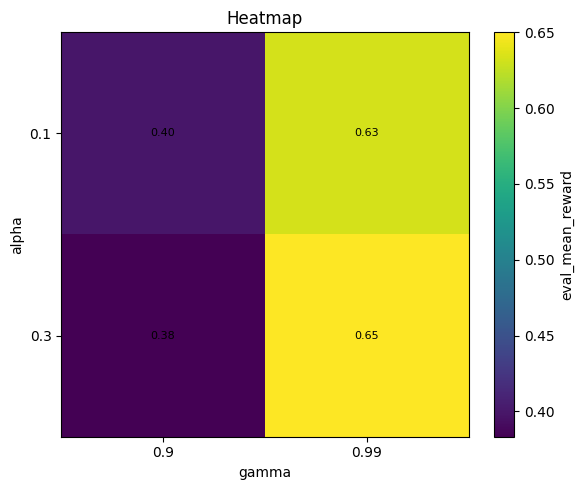

In [41]:
plot_heatmap_annotated(
    small_grid_df,
    x_param="gamma",
    y_param="alpha",
    value="eval_mean_reward"
)

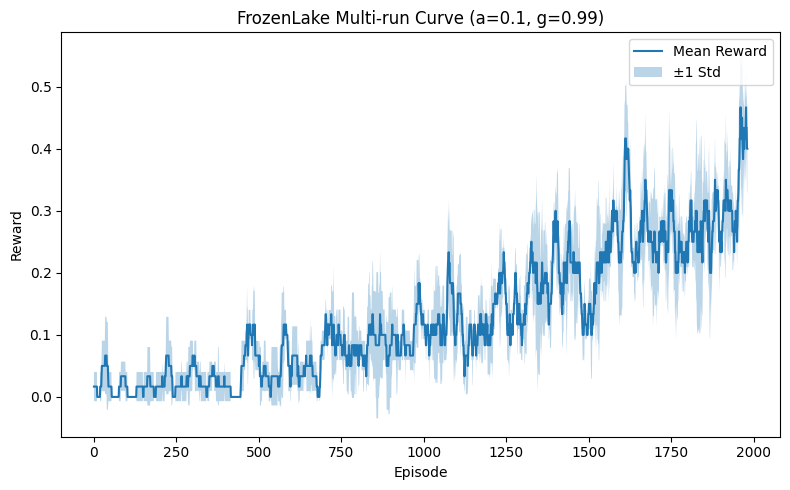

In [42]:
reward_sequences = []

for seed in [0, 1, 2]:
    file_path = f"results/raw/trajectories/frozenlake_a0.1_g0.99_seed{seed}.csv"
    traj_df = pd.read_csv(file_path)
    reward_sequences.append(traj_df["reward"].values)

smoothed_sequences = [
    moving_average(seq, window=20)
    for seq in reward_sequences
]

plot_multi_run_curve(
    smoothed_sequences,
    title="FrozenLake Multi-run Curve (a=0.1, g=0.99)",
    save_path="results/plots/frozenlake_multirun_a0.1_g0.99.png"
)


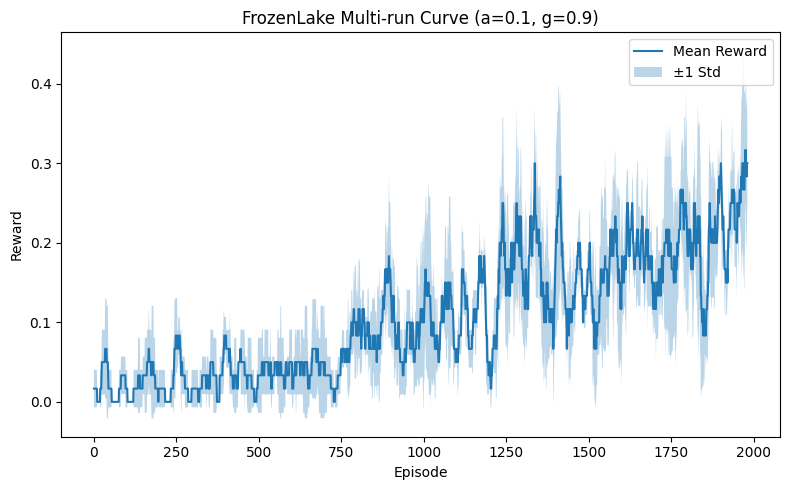

In [43]:
reward_sequences = []

for seed in [0, 1, 2]:
    file_path = f"results/raw/trajectories/frozenlake_a0.1_g0.9_seed{seed}.csv"
    traj_df = pd.read_csv(file_path)
    reward_sequences.append(traj_df["reward"].values)

smoothed_sequences = [
    moving_average(seq, window=20)
    for seq in reward_sequences
]

plot_multi_run_curve(
    smoothed_sequences,
    title="FrozenLake Multi-run Curve (a=0.1, g=0.9)",
    save_path="results/plots/frozenlake_multirun_a0.1_g0.99.png"
)

In [44]:
env.close()

Full Grid Experiment

In [6]:
alphas = [0.05, 0.1, 0.3, 0.5] # Learning rate
gammas = [0.8, 0.9, 0.95, 0.99] # Discount
seeds = [0, 1, 2, 3, 4] # Seeds

In [7]:
records = []

for alpha, gamma, seed in product(alphas, gammas, seeds):
    env = gym.make(
    "FrozenLake-v1",
    is_slippery=True,
)
    state, info = env.reset(seed=seed)

    config = QLearningConfig(
        alpha=alpha,
        gamma=gamma,
        epsilon=1.0,
        epsilon_min=0.05,
        epsilon_decay=0.999,
        n_episodes=1500,
        max_steps_per_episode=100,
        seed=seed,
    )

    agent, training_logs, eval_logs = run_q_learning(env, config)

    record = summarize_run(
        training_logs=training_logs,
        eval_logs=eval_logs,
        config=config,
        env_name="frozenlake",
        seed=seed,
        success_threshold=1.0,
    )

    run_name = make_run_name(config, env_name="frozenlake", seed=seed)

    # Save per-run trajectory
    save_trajectory_csv(
        training_logs,
        f"results/raw/trajectories/{run_name}.csv"
    )

    # Collect summary row
    records.append(record)

    print(
        f"Done: env=frozenlake, alpha={alpha}, gamma={gamma}, seed={seed}, "
        f"eval_mean_reward={eval_logs['mean_reward']:.3f}"
    )

    env.close()

grid_df = records_to_dataframe(records)

save_results_csv(
    grid_df,
    "results/raw/frozenlake_full_grid_summary.csv"
)

grid_df.head()

Done: env=frozenlake, alpha=0.05, gamma=0.8, seed=0, eval_mean_reward=0.300
Done: env=frozenlake, alpha=0.05, gamma=0.8, seed=1, eval_mean_reward=0.250
Done: env=frozenlake, alpha=0.05, gamma=0.8, seed=2, eval_mean_reward=0.200
Done: env=frozenlake, alpha=0.05, gamma=0.8, seed=3, eval_mean_reward=0.250
Done: env=frozenlake, alpha=0.05, gamma=0.8, seed=4, eval_mean_reward=0.150
Done: env=frozenlake, alpha=0.05, gamma=0.9, seed=0, eval_mean_reward=0.150
Done: env=frozenlake, alpha=0.05, gamma=0.9, seed=1, eval_mean_reward=0.400
Done: env=frozenlake, alpha=0.05, gamma=0.9, seed=2, eval_mean_reward=0.000
Done: env=frozenlake, alpha=0.05, gamma=0.9, seed=3, eval_mean_reward=0.500
Done: env=frozenlake, alpha=0.05, gamma=0.9, seed=4, eval_mean_reward=0.100
Done: env=frozenlake, alpha=0.05, gamma=0.95, seed=0, eval_mean_reward=0.200
Done: env=frozenlake, alpha=0.05, gamma=0.95, seed=1, eval_mean_reward=0.300
Done: env=frozenlake, alpha=0.05, gamma=0.95, seed=2, eval_mean_reward=0.600
Done: env

,env,seed,alpha,gamma,epsilon_init,epsilon_min,epsilon_decay,n_episodes,max_steps_per_episode,train_reward_final,...,train_length_last_50_mean,train_length_last_100_mean,success_rate_last_100,first_success_episode,convergence_episode,best_moving_avg_reward_20,eval_mean_reward,eval_std_reward,eval_mean_length,eval_std_length
0,frozenlake,0,0.05,0.8,0.222963,0.05,0.999,1500,100,0.0,...,15.78,15.65,0.18,10,None,0.30,0.30,0.458258,36.25,17.969071
1,frozenlake,1,0.05,0.8,0.222963,0.05,0.999,1500,100,0.0,...,15.72,14.85,0.13,43,None,0.25,0.25,0.433013,25.85,16.891640
2,frozenlake,2,0.05,0.8,0.222963,0.05,0.999,1500,100,0.0,...,17.74,16.45,0.16,39,None,0.30,0.20,0.400000,28.75,16.111719
3,frozenlake,3,0.05,0.8,0.222963,0.05,0.999,1500,100,0.0,...,16.48,15.76,0.16,5,None,0.35,0.25,0.433013,28.45,19.782505
4,frozenlake,4,0.05,0.8,0.222963,0.05,0.999,1500,100,0.0,...,13.62,13.32,0.11,89,None,0.25,0.15,0.357071,23.30,14.966964


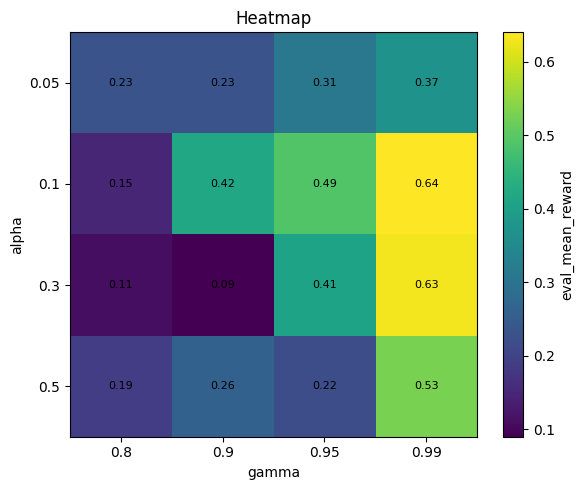

In [8]:
plot_heatmap_annotated(
    grid_df,
    x_param="gamma",
    y_param="alpha",
    value="eval_mean_reward"
)

In [9]:
from src.utils.metrics import moving_average


def smooth_sequences(sequences, window=20):
    return [moving_average(seq, window) for seq in sequences]

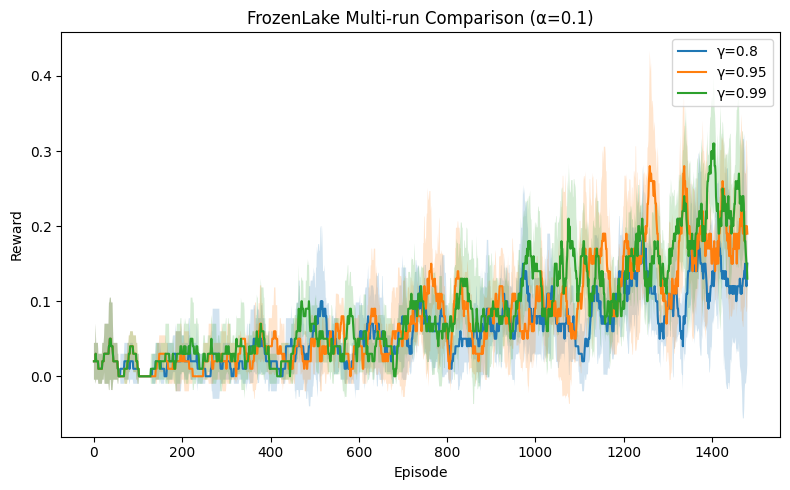

In [10]:
seeds = [0, 1, 2, 3, 4]

seq_08 = load_reward_sequences("frozenlake", 0.1, 0.8, seeds)
seq_095 = load_reward_sequences("frozenlake", 0.1, 0.95, seeds)
seq_099 = load_reward_sequences("frozenlake", 0.1, 0.99, seeds)

seq_08 = smooth_sequences(seq_08)
seq_095 = smooth_sequences(seq_095)
seq_099 = smooth_sequences(seq_099)

curves = {
    "γ=0.8": seq_08,
    "γ=0.95": seq_095,
    "γ=0.99": seq_099,
}

plot_multi_run_comparison(
    curves,
    title="FrozenLake Multi-run Comparison (α=0.1)"
)

Experiment w/ Taxi-v3 ENV

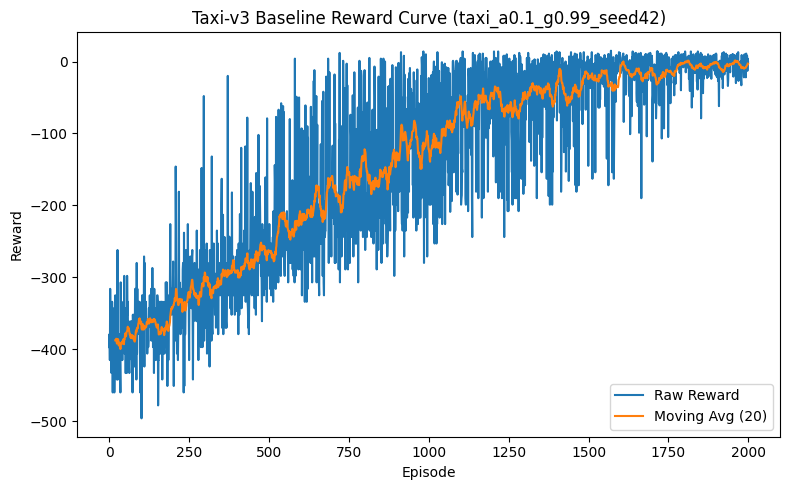

{'mean_reward': -13.8, 'std_reward': 43.1214563761476, 'mean_length': 30.6, 'std_length': 34.7266468292002}


,env,seed,alpha,gamma,epsilon_init,epsilon_min,epsilon_decay,n_episodes,max_steps_per_episode,train_reward_final,...,train_length_last_50_mean,train_length_last_100_mean,success_rate_last_100,first_success_episode,convergence_episode,best_moving_avg_reward_20,eval_mean_reward,eval_std_reward,eval_mean_length,eval_std_length
0,taxi,42,0.1,0.99,0.1352,0.05,0.999,2000,100,0.0,...,16.94,18.84,0.2,722,None,1.45,-13.8,43.121456,30.6,34.726647


In [5]:
# Taxi-v3 baseline
env = make_env("taxi",seed = 42)
# Baseline config for taxi - same as lake's baseline
base_config = QLearningConfig(
    alpha=0.1,
    gamma=0.99,
    epsilon=1.0,
    epsilon_min=0.05,
    epsilon_decay = 0.999,
    n_episodes=2000,
    max_steps_per_episode=100,
    seed=42,
)
agent, training_logs, eval_logs = run_q_learning(env, base_config)

record = summarize_run(
    training_logs=training_logs,
    eval_logs=eval_logs,
    config=base_config,
    env_name="taxi",
    seed=42,
    success_threshold=8.0
)

run_name = make_run_name(base_config, env_name="taxi", seed=42)


# Save summary csv
baseline_df = records_to_dataframe([record])
save_results_csv(
    baseline_df,
    f"results/raw/{run_name}_summary.csv"
)

# Save trajectory csv
save_trajectory_csv(
    training_logs,
    f"results/raw/trajectories/{run_name}.csv"
)

# Draw baseline reward curve
plot_rewards(
    rewards=training_logs["episode_rewards"],
    title=f"Taxi-v3 Baseline Reward Curve ({run_name})",
    save_path=f"results/plots/{run_name}_reward_curve.png",
    smooth_window=20
)

print(eval_logs)
baseline_df.head()

Full Grid Experiment (TAXI ENV)

In [6]:
# Same setting would be used for comparasion
# But since ENV changed to much tougher field, other args could be changed slightly if the performance is bad
alphas = [0.05, 0.1, 0.3, 0.5] # Learning rate
gammas = [0.8, 0.9, 0.95, 0.99] # Discount
seeds = [0, 1, 2, 3, 4] # Seeds

In [7]:
records = []

for alpha, gamma, seed in product(alphas, gammas, seeds):
    env = gym.make("Taxi-v3")
    state, info = env.reset(seed=seed)

    config = QLearningConfig(
        alpha=alpha,
        gamma=gamma,
        epsilon=1.0,
        epsilon_min=0.05,
        epsilon_decay=0.999,
        n_episodes=2000,
        max_steps_per_episode=100,
        seed=seed,
    )

    agent, training_logs, eval_logs = run_q_learning(env, config)

    record = summarize_run(
        training_logs=training_logs,
        eval_logs=eval_logs,
        config=config,
        env_name="taxi",
        seed=seed,
        success_threshold=1.0,
    )

    run_name = make_run_name(config, env_name="taxi", seed=seed)

    # Save per-run trajectory
    save_trajectory_csv(
        training_logs,
        f"results/raw/trajectories/{run_name}.csv"
    )

    # Collect summary row
    records.append(record)

    print(
        f"Done: env=taxi, alpha={alpha}, gamma={gamma}, seed={seed}, "
        f"eval_mean_reward={eval_logs['mean_reward']:.3f}"
    )

    env.close()

grid_df = records_to_dataframe(records)

save_results_csv(
    grid_df,
    "results/raw/taxi_full_grid_summary.csv"
)

grid_df.head()

Done: env=taxi, alpha=0.05, gamma=0.8, seed=0, eval_mean_reward=-83.000
Done: env=taxi, alpha=0.05, gamma=0.8, seed=1, eval_mean_reward=-77.500
Done: env=taxi, alpha=0.05, gamma=0.8, seed=2, eval_mean_reward=-83.000
Done: env=taxi, alpha=0.05, gamma=0.8, seed=3, eval_mean_reward=-83.000
Done: env=taxi, alpha=0.05, gamma=0.8, seed=4, eval_mean_reward=-83.000
Done: env=taxi, alpha=0.05, gamma=0.9, seed=0, eval_mean_reward=-72.250
Done: env=taxi, alpha=0.05, gamma=0.9, seed=1, eval_mean_reward=-77.600
Done: env=taxi, alpha=0.05, gamma=0.9, seed=2, eval_mean_reward=-83.000
Done: env=taxi, alpha=0.05, gamma=0.9, seed=3, eval_mean_reward=-83.000
Done: env=taxi, alpha=0.05, gamma=0.9, seed=4, eval_mean_reward=-83.000
Done: env=taxi, alpha=0.05, gamma=0.95, seed=0, eval_mean_reward=-77.500
Done: env=taxi, alpha=0.05, gamma=0.95, seed=1, eval_mean_reward=-77.550
Done: env=taxi, alpha=0.05, gamma=0.95, seed=2, eval_mean_reward=-67.150
Done: env=taxi, alpha=0.05, gamma=0.95, seed=3, eval_mean_rew

,env,seed,alpha,gamma,epsilon_init,epsilon_min,epsilon_decay,n_episodes,max_steps_per_episode,train_reward_final,...,train_length_last_50_mean,train_length_last_100_mean,success_rate_last_100,first_success_episode,convergence_episode,best_moving_avg_reward_20,eval_mean_reward,eval_std_reward,eval_mean_length,eval_std_length
0,taxi,0,0.05,0.8,0.1352,0.05,0.999,2000,100,-42.0,...,55.00,58.46,0.09,1059,NaN,-43.40,-83.0,40.470977,86.15,32.973133
1,taxi,1,0.05,0.8,0.1352,0.05,0.999,2000,100,-12.0,...,59.28,61.02,0.07,1127,NaN,-49.70,-77.5,45.007222,81.70,36.608879
2,taxi,2,0.05,0.8,0.1352,0.05,0.999,2000,100,1.0,...,59.92,60.76,0.08,663,NaN,-52.15,-83.0,40.470977,86.15,32.973133
3,taxi,3,0.05,0.8,0.1352,0.05,0.999,2000,100,-64.0,...,60.78,60.99,0.11,507,NaN,-50.40,-83.0,40.470977,86.15,32.973133
4,taxi,4,0.05,0.8,0.1352,0.05,0.999,2000,100,-3.0,...,61.50,64.57,0.06,1022,NaN,-56.80,-83.0,40.470977,86.15,32.973133


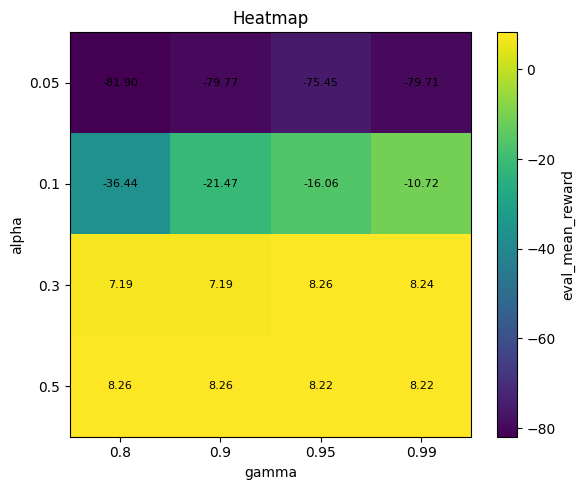

In [8]:
plot_heatmap_annotated(
    grid_df,
    x_param="gamma",
    y_param="alpha",
    value="eval_mean_reward"
)

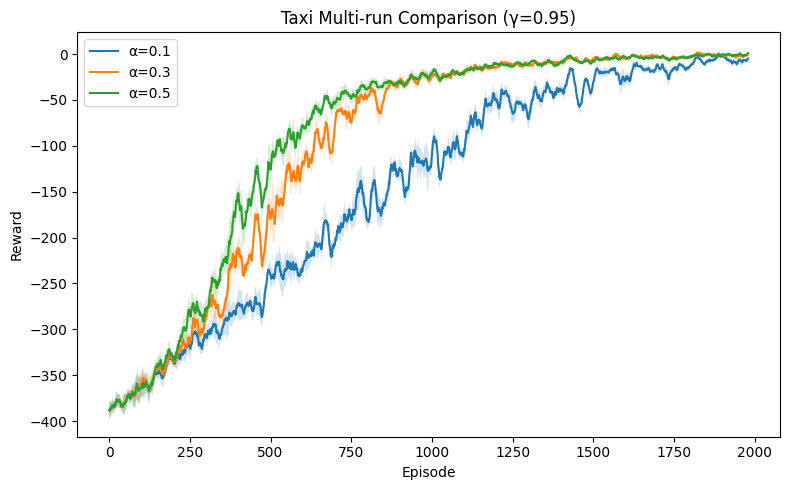

In [11]:
seeds = [0, 1, 2, 3, 4]

seq_08 = load_reward_sequences("taxi", 0.1, 0.95, seeds)
seq_095 = load_reward_sequences("taxi", 0.3, 0.95, seeds)
seq_099 = load_reward_sequences("taxi", 0.5, 0.95, seeds)

seq_08 = smooth_sequences(seq_08)
seq_095 = smooth_sequences(seq_095)
seq_099 = smooth_sequences(seq_099)

curves = {
    "α=0.1": seq_08,
    "α=0.3": seq_095,
    "α=0.5": seq_099,
}

plot_multi_run_comparison(
    curves,
    title="Taxi Multi-run Comparison (γ=0.95)"
)